# Лабораторная работа №1 — Основы обработки текста

**Темы:** слова и токены (гл. 2), редакционное расстояние (гл. 2), N-граммовые языковые модели (гл. 3).

**Корпус:** «Каштанка» А. П. Чехова (1887) — берём с Русской Викитеки, ~6 тыс. слов, современная орфография.

Структура:
1. Часть 1 — токенизация и статистика (30%).
2. Часть 2 — редакционное расстояние (30%).
3. Часть 3 — N-граммовые языковые модели (40%).

In [1]:
import os
import re
import math
import string
import random
import urllib.request
import urllib.parse
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nltk
for pkg in ['punkt', 'punkt_tab']:
    try:
        nltk.data.find(f'tokenizers/{pkg}')
    except LookupError:
        nltk.download(pkg, quiet=True)

from nltk.tokenize import word_tokenize, sent_tokenize

random.seed(42)
np.random.seed(42)
plt.rcParams['figure.dpi'] = 100
print('Версии:', 'numpy', np.__version__, '| pandas', pd.__version__, '| nltk', nltk.__version__)

Версии: numpy 2.4.6 | pandas 3.0.3 | nltk 3.9.4


## Часть 1 — Токенизация и статистика (30%)

### Шаг 1. Скачиваем текст
Берём «Каштанку» с Русской Викитеки (`action=raw` отдаёт wiki-разметку — её чистим простыми regex), сохраняем в `data/kashtanka.txt`. Если файл уже есть — используем кэш.

In [2]:
DATA_PATH = 'data/kashtanka.txt'
URL_TITLE = 'Каштанка_(Чехов)'

def strip_wiki(raw: str) -> str:
    # Итеративно убираем шаблоны {{...}} (учитывая вложенные)
    prev = None
    while prev != raw:
        prev = raw
        raw = re.sub(r'\{\{[^{}]*\}\}', ' ', raw)
    # Внешние таблицы {| ... |}
    raw = re.sub(r'\{\|.*?\|\}', ' ', raw, flags=re.DOTALL)
    # Иногда остаются висячие |КЛЮЧ=значение строки от шаблонов с переносом
    raw = re.sub(r'(?m)^\|[^=\n]*=.*$', '', raw)
    # html-теги и ссылки
    raw = re.sub(r'<ref[^>]*>.*?</ref>', ' ', raw, flags=re.DOTALL)
    raw = re.sub(r'<[^>]+>', ' ', raw)
    raw = re.sub(r"'{2,}", '', raw)
    raw = re.sub(r'\[\[[^\]\|]*\|([^\]]+)\]\]', r'\1', raw)  # [[Foo|bar]] -> bar
    raw = re.sub(r'\[\[([^\]]+)\]\]', r'\1', raw)            # [[bar]] -> bar
    raw = re.sub(r'\[[^\s\]]+\s+([^\]]+)\]', r'\1', raw)     # внешние ссылки
    raw = re.sub(r'={2,}.*?={2,}', '\n', raw)                # заголовки
    raw = re.sub(r'&nbsp;', ' ', raw)
    raw = re.sub(r'&[a-z]+;', ' ', raw)
    raw = re.sub(r'[ \t]+', ' ', raw)
    raw = re.sub(r'\n{2,}', '\n\n', raw)
    return raw.strip()

def fetch_corpus(path=DATA_PATH, title=URL_TITLE):
    if os.path.exists(path):
        with open(path, 'r', encoding='utf-8') as f:
            return f.read()
    encoded_title = urllib.parse.quote(title, safe='')
    url = f'https://ru.wikisource.org/wiki/{encoded_title}?action=raw'
    req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
    with urllib.request.urlopen(req, timeout=30) as resp:
        raw = resp.read().decode('utf-8')
    cleaned = strip_wiki(raw)
    os.makedirs(os.path.dirname(path), exist_ok=True)
    with open(path, 'w', encoding='utf-8') as f:
        f.write(cleaned)
    return cleaned

# Удаляем кэш, чтобы перекачать с новой очисткой
if os.path.exists(DATA_PATH):
    os.remove(DATA_PATH)
text = fetch_corpus()
print(f'Длина: {len(text):,} символов')
print(f'Слов (по пробелам, грубо): {len(text.split()):,}')
print('---')
print(text[:500])

Длина: 36,858 символов
Слов (по пробелам, грубо): 5,974
---
Молодая рыжая собака — помесь такса с дворняжкой — очень похожая мордой на лисицу, бегала взад и вперёд по тротуару и беспокойно оглядывалась по сторонам. Изредка она останавливалась и, плача, приподнимая то одну озябшую лапу, то другую, старалась дать себе отчёт: как это могло случиться, что она заблудилась?

Она отлично помнила, как она провела день и как в конце концов попала на этот незнакомый тротуар.

День начался с того, что её хозяин, столяр Лука Александрыч, надел шапку, взял под мышку 


### Шаг 2. Две токенизации: split() vs nltk.word_tokenize()

In [3]:
tokens_split = text.split()
tokens_nltk = word_tokenize(text, language='russian')

print('=== Первые 20 токенов через text.split() ===')
print(tokens_split[:20])
print()
print('=== Первые 20 токенов через nltk.word_tokenize() ===')
print(tokens_nltk[:20])

=== Первые 20 токенов через text.split() ===
['Молодая', 'рыжая', 'собака', '—', 'помесь', 'такса', 'с', 'дворняжкой', '—', 'очень', 'похожая', 'мордой', 'на', 'лисицу,', 'бегала', 'взад', 'и', 'вперёд', 'по', 'тротуару']

=== Первые 20 токенов через nltk.word_tokenize() ===
['Молодая', 'рыжая', 'собака', '—', 'помесь', 'такса', 'с', 'дворняжкой', '—', 'очень', 'похожая', 'мордой', 'на', 'лисицу', ',', 'бегала', 'взад', 'и', 'вперёд', 'по']


**Чем различаются:** `text.split()` режет ровно по пробелам — знаки препинания «прилипают» к словам (`«Каштанка»,`, `— смешанной`). `nltk.word_tokenize()` отделяет пунктуацию в отдельные токены и нормально обрабатывает кавычки, тире, точки. Для статистики и языковых моделей правильный путь — второй.

### Шаг 3. Нормализация: lowercase + удаление пунктуации

In [4]:
PUNCT = set(string.punctuation) | set('«»—–…“”„‘’`№•·')

def is_word(tok):
    return bool(tok) and not all(ch in PUNCT for ch in tok)

tokens = [t.lower() for t in tokens_nltk if is_word(t)]
print(f'Всего токенов после нормализации: {len(tokens):,}')
print('Пример:', tokens[:30])

Всего токенов после нормализации: 5,844
Пример: ['молодая', 'рыжая', 'собака', 'помесь', 'такса', 'с', 'дворняжкой', 'очень', 'похожая', 'мордой', 'на', 'лисицу', 'бегала', 'взад', 'и', 'вперёд', 'по', 'тротуару', 'и', 'беспокойно', 'оглядывалась', 'по', 'сторонам', 'изредка', 'она', 'останавливалась', 'и', 'плача', 'приподнимая', 'то']


### Шаг 4. Статистика корпуса: N, V и топ-20 частот

In [5]:
N = len(tokens)
V = len(set(tokens))
print(f'Общее число токенов  N = {N:,}')
print(f'Размер словаря        V = {V:,}')
print(f'Type/Token Ratio     V/N = {V/N:.3f}')

freq = Counter(tokens)
top20 = freq.most_common(20)
df_top = pd.DataFrame(top20, columns=['слово', 'частота'])
df_top

Общее число токенов  N = 5,844
Размер словаря        V = 2,377
Type/Token Ratio     V/N = 0.407


,слово,частота
0,и,402
1,в,137
2,на,118
3,не,88
4,с,80
5,что,73
6,он,73
7,она,71
8,каштанка,46
9,хозяин,45


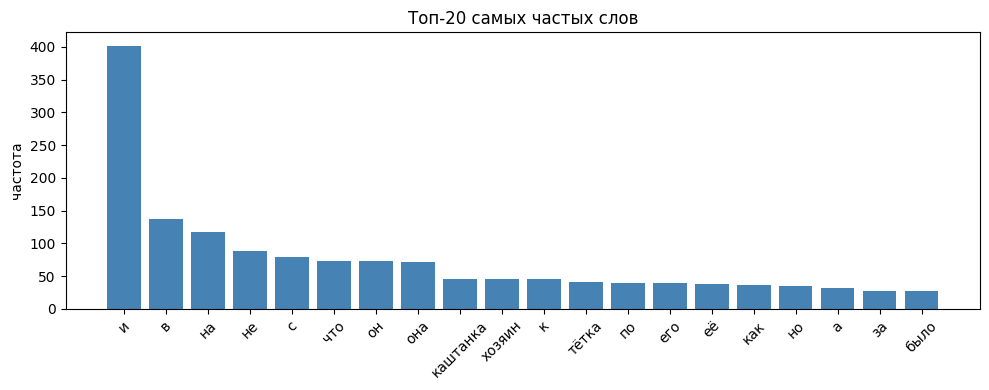

In [6]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(df_top['слово'], df_top['частота'], color='steelblue')
ax.set_title('Топ-20 самых частых слов')
ax.set_ylabel('частота')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

### Шаг 5. График Ципфа

Закон Ципфа: частота `f(r)` слова ранга `r` примерно обратно пропорциональна рангу: `f ∝ 1/r`. В лог-лог осях это даёт **прямую линию с угловым коэффициентом ≈ −1**. Так устроены практически все естественные тексты.

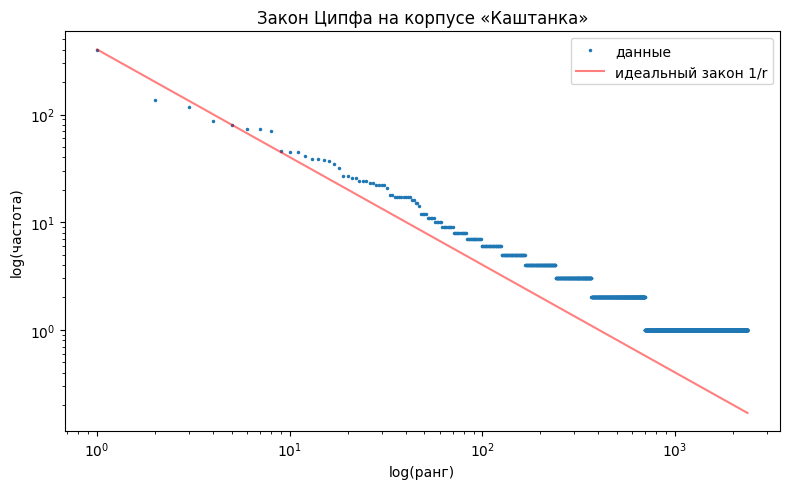

In [7]:
freqs_sorted = np.array([c for _, c in freq.most_common()])
ranks = np.arange(1, len(freqs_sorted) + 1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(ranks, freqs_sorted, marker='.', linestyle='', markersize=3, label='данные')
# Идеальная прямая f = N/r * c
ideal = freqs_sorted[0] / ranks
ax.loglog(ranks, ideal, 'r-', alpha=0.5, label='идеальный закон 1/r')
ax.set_xlabel('log(ранг)')
ax.set_ylabel('log(частота)')
ax.set_title('Закон Ципфа на корпусе «Каштанка»')
ax.legend()
plt.tight_layout()
plt.show()

**Почему такая форма.** Естественный язык чрезвычайно неравномерен: десяток служебных слов («и», «не», «в», «он», «она»…) забирают значительную долю всех вхождений, а длинный хвост — это редкие слова, многие из которых встретятся ровно один раз (т.н. *hapax legomena*). Хвост на лог-лог графике обычно слегка отклоняется от идеальной прямой — это эффект конечного словаря.

## Часть 2 — Редакционное расстояние (30%)

### Шаг 6. Своя реализация на DP

Заполняем матрицу `dp[i][j]` = минимальная стоимость преобразовать первые `i` символов `s1` в первые `j` символов `s2`. Ответ — `dp[len(s1)][len(s2)]`. Стоимость каждой операции (вставка/удаление/замена) = 1.

In [8]:
def edit_distance(s1: str, s2: str):
    n, m = len(s1), len(s2)
    dp = np.zeros((n + 1, m + 1), dtype=int)
    dp[:, 0] = np.arange(n + 1)
    dp[0, :] = np.arange(m + 1)
    for i in range(1, n + 1):
        for j in range(1, m + 1):
            cost = 0 if s1[i-1] == s2[j-1] else 1
            dp[i, j] = min(
                dp[i-1, j] + 1,        # удаление
                dp[i, j-1] + 1,        # вставка
                dp[i-1, j-1] + cost,   # замена
            )
    return int(dp[n, m]), dp

def show_matrix(s1, s2):
    d, m = edit_distance(s1, s2)
    cols = ['ε'] + list(s2)
    rows = ['ε'] + list(s1)
    df = pd.DataFrame(m, index=rows, columns=cols)
    print(f'{s1!r} → {s2!r}  расстояние = {d}')
    return df

### Шаг 7. Проверка на учебных примерах + 6 дополнительных

In [9]:
tests = [
    ('кот', 'кот'),
    ('кот', 'код'),
    ('мама', 'рама'),
    ('intention', 'execution'),
    ('доктор', 'тостер'),
    ('привет', 'превед'),
    ('kitten', 'sitting'),
    ('Sunday', 'Saturday'),
    ('алгоритм', 'логарифм'),
    ('cat', 'cats'),
]
summary = []
for s1, s2 in tests:
    d, _ = edit_distance(s1, s2)
    summary.append({'s1': s1, 's2': s2, 'distance': d})
pd.DataFrame(summary)

,s1,s2,distance
0,кот,кот,0
1,кот,код,1
2,мама,рама,1
3,intention,execution,5
4,доктор,тостер,3
5,привет,превед,2
6,kitten,sitting,3
7,Sunday,Saturday,3
8,алгоритм,логарифм,4
9,cat,cats,1


In [10]:
# Покажем матрицы для пары первых четырёх пар (по требованию задания)
for s1, s2 in tests[:4]:
    display = show_matrix(s1, s2)
    print(display)
    print()

'кот' → 'кот'  расстояние = 0
   ε  к  о  т
ε  0  1  2  3
к  1  0  1  2
о  2  1  0  1
т  3  2  1  0

'кот' → 'код'  расстояние = 1
   ε  к  о  д
ε  0  1  2  3
к  1  0  1  2
о  2  1  0  1
т  3  2  1  1

'мама' → 'рама'  расстояние = 1
   ε  р  а  м  а
ε  0  1  2  3  4
м  1  1  2  2  3
а  2  2  1  2  2
м  3  3  2  1  2
а  4  4  3  2  1

'intention' → 'execution'  расстояние = 5
   ε  e  x  e  c  u  t  i  o  n
ε  0  1  2  3  4  5  6  7  8  9
i  1  1  2  3  4  5  6  6  7  8
n  2  2  2  3  4  5  6  7  7  7
t  3  3  3  3  4  5  5  6  7  8
e  4  3  4  3  4  5  6  6  7  8
n  5  4  4  4  4  5  6  7  7  7
t  6  5  5  5  5  5  5  6  7  8
i  7  6  6  6  6  6  6  5  6  7
o  8  7  7  7  7  7  7  6  5  6
n  9  8  8  8  8  8  8  7  6  5



### Шаг 8. Применение — поиск ближайших слов по словарю корпуса

In [11]:
vocab = sorted(set(tokens))

def nearest_words(typo, k=5):
    typo = typo.lower()
    scored = [(w, edit_distance(typo, w)[0]) for w in vocab]
    scored.sort(key=lambda x: (x[1], x[0]))
    return scored[:k]

typos = ['чехав', 'каштнка', 'хазяин', 'лошат', 'спрашевал']
for t in typos:
    print(f'{t:>12} →', nearest_words(t))

       чехав → [('чехова', 2), ('вела', 3), ('делал', 3), ('делая', 3), ('ела', 3)]
     каштнка → [('каштанка', 1), ('каштанке', 2), ('каштанки', 2), ('каштанку', 2), ('каштанкою', 3)]
      хазяин → [('хозяин', 1), ('хозяина', 2), ('хозяев', 3), ('хозяином', 3), ('вами', 4)]
       лошат → [('лошади', 2), ('лошадь', 2), ('боках', 3), ('брат', 3), ('ворот', 3)]
   спрашевал → [('спрашивая', 2), ('права', 4), ('пробежал', 4), ('спрятал', 4), ('впадал', 5)]


**Работает ли метод?** Для коротких опечаток в одну букву — да, попадаем в нужное слово или близкое к нему. Но метод плох, когда:
- словарь ограничен данным текстом (отсутствуют редкие формы);
- опечатка большой длины (расстояние 3+ возвращает «шумные» варианты);
- замены равноправны: `чехав → чехов` и `чехав → дрова` обе стоят 1.

На практике используют взвешенный (по клавиатуре/фонетике) Левенштейн + языковую модель для выбора лучшего кандидата.

## Часть 3 — N-граммовые языковые модели (40%)

### Шаг 9. Разбиение на train/test

In [12]:
def normalize_sentence(sent):
    toks = word_tokenize(sent, language='russian')
    return [t.lower() for t in toks if is_word(t)]

sents = sent_tokenize(text, language='russian')
norm_sents = [normalize_sentence(s) for s in sents]
norm_sents = [s for s in norm_sents if len(s) >= 2]
print(f'Предложений: {len(norm_sents):,}')

split_at = int(0.8 * len(norm_sents))
train_sents = norm_sents[:split_at]
test_sents = norm_sents[split_at:]
train_tokens = sum(train_sents, [])
test_tokens = sum(test_sents, [])
print(f'Train: {len(train_sents)} предлож. / {len(train_tokens)} токенов')
print(f'Test:  {len(test_sents)} предлож. / {len(test_tokens)} токенов')

Предложений: 394
Train: 315 предлож. / 4568 токенов
Test:  79 предлож. / 1254 токенов


### Шаг 10. Биграммная модель: частоты и MLE-вероятности

In [13]:
BOS = '<s>'
EOS = '</s>'

def make_ngrams(sentences, n):
    pad_left = [BOS] * (n - 1)
    grams = []
    for s in sentences:
        seq = pad_left + s + [EOS]
        for i in range(len(seq) - n + 1):
            grams.append(tuple(seq[i:i+n]))
    return grams

unigrams_train = make_ngrams(train_sents, 1)
bigrams_train = make_ngrams(train_sents, 2)
unigram_counts = Counter(unigrams_train)
bigram_counts = Counter(bigrams_train)
# count(w_{n-1}) -- слова, встречавшиеся как левый контекст
context_counts = Counter(b[0] for b in bigrams_train)
context_counts[BOS] = len(train_sents)

vocab_train = set(t for s in train_sents for t in s) | {BOS, EOS}
V_train = len(vocab_train)
print(f'Уникальных биграмм: {len(bigram_counts):,}')
print(f'Словарь обучения V = {V_train:,}')
print('Примеры частот:')
for bg, c in bigram_counts.most_common(10):
    print(f'  {bg}: {c}')

Уникальных биграмм: 4,153
Словарь обучения V = 1,908
Примеры частот:
  ('иван', 'иваныч'): 22
  ('<s>', 'каштанка'): 16
  ('<s>', 'он'): 13
  ('<s>', 'тётка'): 13
  ('<s>', 'она'): 12
  ('и', 'в'): 12
  ('фёдор', 'тимофеич'): 12
  ('<s>', 'и'): 11
  ('и', 'не'): 10
  ('<s>', 'в'): 9


In [14]:
def p_mle(w_prev, w):
    return bigram_counts.get((w_prev, w), 0) / context_counts[w_prev] if context_counts[w_prev] else 0.0

# Несколько проб
for ctx, w in [('она', 'была'), ('он', 'был'), ('каштанка', 'и'), (BOS, 'она')]:
    print(f'P({w!r} | {ctx!r}) = {p_mle(ctx, w):.4f}')

P('была' | 'она') = 0.0323
P('был' | 'он') = 0.0545
P('и' | 'каштанка') = 0.0286
P('она' | '<s>') = 0.0381


### Шаг 11. Сглаживание Лапласа (add-1)

Формула: `P_lap(w_n | w_{n-1}) = (count(w_{n-1}, w_n) + 1) / (count(w_{n-1}) + V)`.

**Зачем сглаживание.** Без него любая биграмма, не виденная при обучении, получит вероятность 0. Перплексия теста (произведение вероятностей в знаменателе) тогда уходит в **бесконечность** на первой же незнакомой биграмме. Add-1 «откусывает» по чуть-чуть массы у виденных биграмм и раздаёт всем — простой и грубый, но не ломается.

In [15]:
def p_laplace_bi(w_prev, w, V=V_train):
    return (bigram_counts.get((w_prev, w), 0) + 1) / (context_counts[w_prev] + V)

# Сравнение виденная vs невиденная биграмма
for ctx, w in [('она', 'была'), ('каштанка', 'квакала')]:
    print(f'MLE     P({w!r}|{ctx!r}) = {p_mle(ctx, w):.6f}')
    print(f'Laplace P({w!r}|{ctx!r}) = {p_laplace_bi(ctx, w):.6f}')
    print()

MLE     P('была'|'она') = 0.032258
Laplace P('была'|'она') = 0.001523

MLE     P('квакала'|'каштанка') = 0.000000
Laplace P('квакала'|'каштанка') = 0.000515



### Шаг 12. Генерация предложений по биграммной модели

In [16]:
# Для скорости: предвычислим следующие слова для каждого контекста
next_words = defaultdict(list)
next_weights = defaultdict(list)
for (w1, w2), c in bigram_counts.items():
    next_words[w1].append(w2)
    next_weights[w1].append(c)

def generate_sentence(start=None, min_len=10, max_len=15, seed=None):
    rng = random.Random(seed)
    if start is None:
        start = rng.choices(next_words[BOS], weights=next_weights[BOS])[0]
    sent = [start]
    prev = start
    while len(sent) < max_len:
        choices = next_words.get(prev)
        if not choices:
            break
        nxt = rng.choices(choices, weights=next_weights[prev])[0]
        if nxt == EOS:
            if len(sent) >= min_len:
                break
            # «короткое» предложение — продолжаем со случайного частого слова
            prev = rng.choices(next_words[BOS], weights=next_weights[BOS])[0]
            sent.append(prev)
            continue
        sent.append(nxt)
        prev = nxt
    return ' '.join(sent)

for i in range(3):
    print(f'{i+1}. {generate_sentence(seed=i)}')

1. несомненный талант нужно было тихо тонким голоском ску-ску-ску… в спальню хозяина по опыту что же
2. он умирает если бы ты поступил в одном из большой светлой комнате и оглядываясь каштанка
3. вздохнул хозяин не было мало тётка закрыла глаза у него есть сильно дёргал её на


**Качество на глаз.** Биграммы дают грамматически локально связные куски («он не», «была собака»), но смысл рассыпается уже через 3–4 слова — модель не видит дальше одного слова назад. Имена и редкие слова всплывают неожиданно. Триграмма обычно даёт более связный результат на длинных корпусах.

### Шаг 13. Перплексия: биграммная vs триграммная

`PP(W) = exp(-1/N * Σ log P(w_i | context))`. Меньше — лучше.

In [17]:
def perplexity_bigram(test_sents, bigram_counts, context_counts, V):
    log_sum = 0.0
    N_tokens = 0
    for s in test_sents:
        seq = [BOS] + s + [EOS]
        for i in range(1, len(seq)):
            p = (bigram_counts.get((seq[i-1], seq[i]), 0) + 1) / (context_counts.get(seq[i-1], 0) + V)
            log_sum += math.log(p)
            N_tokens += 1
    return math.exp(-log_sum / N_tokens)

def perplexity_trigram(test_sents, trigram_counts, bigram_ctx_counts, V):
    log_sum = 0.0
    N_tokens = 0
    for s in test_sents:
        seq = [BOS, BOS] + s + [EOS]
        for i in range(2, len(seq)):
            ctx = (seq[i-2], seq[i-1])
            p = (trigram_counts.get((seq[i-2], seq[i-1], seq[i]), 0) + 1) / (bigram_ctx_counts.get(ctx, 0) + V)
            log_sum += math.log(p)
            N_tokens += 1
    return math.exp(-log_sum / N_tokens)

# Триграммная модель: считаем счётчики
trigrams_train = make_ngrams(train_sents, 3)
trigram_counts = Counter(trigrams_train)
trigram_ctx_counts = Counter((tg[0], tg[1]) for tg in trigrams_train)

pp_bi = perplexity_bigram(test_sents, bigram_counts, context_counts, V_train)
pp_tri = perplexity_trigram(test_sents, trigram_counts, trigram_ctx_counts, V_train)
print(f'Перплексия (Laplace): биграмма = {pp_bi:.2f}')
print(f'Перплексия (Laplace): триграмма = {pp_tri:.2f}')

Перплексия (Laplace): биграмма = 1612.53
Перплексия (Laplace): триграмма = 1758.46


**Объяснение.** На небольшом корпусе триграмма обычно даёт **хуже** (выше перплексию), хотя теоретически контекста больше. Причина — sparsity: число возможных триграмм ~`V^3`, а в обучении видится лишь горстка. Add-1 с гигантским знаменателем `V_train` размазывает массу очень тонко → каждая редкая триграмма получает крошечную вероятность. На большом корпусе картина обратная — там триграмма выигрывает.

### Шаг 14. Зависимость перплексии от размера train

In [18]:
sizes = [0.10, 0.25, 0.50, 0.80]
results = []
for frac in sizes:
    cut = int(frac * len(norm_sents))
    tr = norm_sents[:cut]
    if not tr:
        continue
    bi = Counter(make_ngrams(tr, 2))
    ctx = Counter(b[0] for b in bi.elements())
    ctx[BOS] = len(tr)
    voc = set(t for s in tr for t in s) | {BOS, EOS}
    pp = perplexity_bigram(test_sents, bi, ctx, len(voc))
    results.append({'fraction': frac, 'train_sents': len(tr), 'V': len(voc), 'perplexity': pp})
df_pp = pd.DataFrame(results)
df_pp

,fraction,train_sents,V,perplexity
0,0.10,39,455,448.386737
1,0.25,98,920,873.416135
2,0.50,197,1510,1358.756570
3,0.80,315,1908,1612.526849


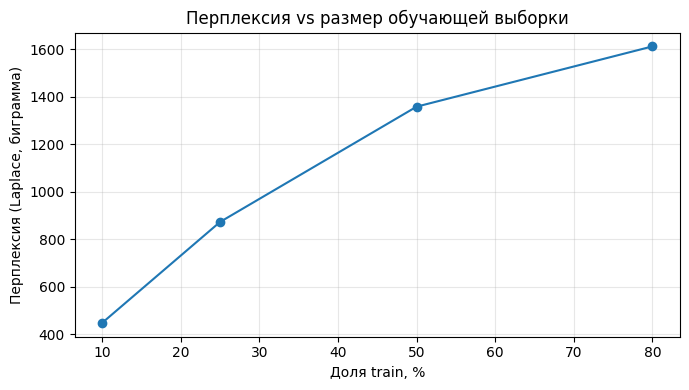

In [19]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(df_pp['fraction'] * 100, df_pp['perplexity'], marker='o')
ax.set_xlabel('Доля train, %')
ax.set_ylabel('Перплексия (Laplace, биграмма)')
ax.set_title('Перплексия vs размер обучающей выборки')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Что видим.** С ростом train перплексия снижается монотонно: больше данных → больше знакомых биграмм в тесте → меньше штрафа от add-1. Кривая выходит на плато: после некоторого момента дополнительные данные дают всё меньше выигрыша (закон убывающей отдачи).

---

### Итог Лабораторной №1

- **Часть 1:** скачали корпус (~6 тыс. слов), сравнили две токенизации, нормализовали, посчитали `N`, `V`, посмотрели топ-20 и подтвердили закон Ципфа на лог-лог графике.
- **Часть 2:** реализовали Левенштейна на DP, проверили на 10 парах, использовали как простую модель исправления опечаток.
- **Часть 3:** построили биграммную и триграммную LM с add-1 сглаживанием, сгенерировали текст, замерили перплексию (триграмма проигрывает на маленьком корпусе из-за sparsity), показали зависимость перплексии от размера train.